In [1]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, roc_auc_score,average_precision_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, recall_score, precision_score, f1_score, balanced_accuracy_score
import seaborn as sns
import torch.nn.functional as F
import math
from tqdm import tqdm
import os
import pickle
from torch.optim.lr_scheduler import ReduceLROnPlateau
import random

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Set random seeds for reproducibility
random.seed(666)
np.random.seed(666)
torch.manual_seed(666)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(666)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
# Load data (adjust paths as needed)
df_train = pd.read_csv('C:/Users/wenzh/Desktop/Model_test/Model_construction_train_data.csv') 
df = df_train
df1 = pd.read_csv('C:/Users/wenzh/Desktop/Model_test/input_meta_train.csv')
df1 = df1[['ID','Label','patient_id']]
df1 = df1[df1['ID'].isin(df['ID'])]

In [5]:
# Patient split code...
patient_stats = df1.groupby('patient_id').agg(
    total_samples=('Label', 'count'),
    positive_ratio=('Label', lambda x: (x == 'Neo').mean())
).reset_index()
patient_ids_to_samples = df1.groupby('patient_id')['ID'].apply(list).to_dict()
patient_stats['samples'] = patient_stats['patient_id'].map(patient_ids_to_samples)
val_size=0.05
max_iter=10000

In [6]:
best_diff = float('inf')
best_train = None
best_val = None
overall_positive_ratio = (df1['Label'] == 'Neo').mean()

In [7]:
for _ in range(max_iter):
    shuffled = patient_stats.sample(frac=1)
    cum_samples = 0
    cum_positive = 0
    train_patients = []
    for _, row in shuffled.iterrows():
        new_total = cum_samples + row['total_samples']
        new_positive = cum_positive + row['positive_ratio'] * row['total_samples'] 
        if abs(1 - new_total / len(df1) - val_size) > 0.05: 
            train_patients.append(row)
            cum_samples = new_total
            cum_positive = new_positive
        else:
            break
    val_patients = shuffled[~shuffled['patient_id'].isin([p['patient_id'] for p in train_patients])]
    if cum_samples == 0:
        train_ratio = 0
    else:
        train_ratio = cum_positive / cum_samples
    val_positive = (df1[df1['patient_id'].isin(val_patients['patient_id'])]['Label'] == 'Neo').sum()
    val_ratio = val_positive / (len(df1) - cum_samples) if cum_samples < len(df1) else 0
    diff = abs(train_ratio - val_ratio)
    if diff < best_diff:
        best_diff = diff
        best_train = train_patients
        best_val = val_patients
train_ids = [sample for p in best_train for sample in p['samples']]
try:
    val_ids = [sample for p in best_val for sample in p['samples']]
except:
    val_ids = []
    for sample in best_val['samples']:
        val_ids.extend(sample)

In [8]:
train_set = df[df['ID'].isin(train_ids)].copy()
val_set = df[df['ID'].isin(val_ids)].copy()
print(f"Training set size: {len(train_set)} samples")
print(f"val set size: {len(val_set)} samples")
print(f"Training set positive ratio: {100*(train_set['Label']=='Neo').mean():.2f}%")
print(f"val set positive ratio: {100*(val_set['Label']=='Neo').mean():.2f}%")

Training set size: 35298 samples
val set size: 7653 samples
Training set positive ratio: 23.99%
val set positive ratio: 25.60%


In [9]:
class TCellClassifier(nn.Module):
    def __init__(self, n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf,
                 property_vocab_size=6, max_len_a=23, max_len_b=26,
                 gene_hidden=128, embed_dim_aa_props=32, embed_dim_ct=32, embed_dim_cell=8, embed_dim_hp=2,
                 quantum_rnn_hidden=64, num_heads=4):
        super(TCellClassifier, self).__init__()
        
        # Embedding layers
        self.embed_trav = nn.Embedding(n_trav, embed_dim_ct)
        self.embed_traj = nn.Embedding(n_traj, embed_dim_ct)
        self.embed_trbv = nn.Embedding(n_trbv, embed_dim_ct)
        self.embed_trbd = nn.Embedding(n_trbd, embed_dim_ct)
        self.embed_trbj = nn.Embedding(n_trbj, embed_dim_ct)
        self.embed_cell = nn.Embedding(n_celltype, embed_dim_cell)
        self.embed_hpv = nn.Embedding(n_hpvinf, embed_dim_hp)
        self.embed_aa_properties = nn.Embedding(property_vocab_size, embed_dim_aa_props, padding_idx=0)
        
        # Quantum RNN
        self.quantum_rnn_alpha = QuantumInspiredRNN(input_dim=embed_dim_aa_props, output_dim=quantum_rnn_hidden)
        self.quantum_rnn_beta = QuantumInspiredRNN(input_dim=embed_dim_aa_props, output_dim=quantum_rnn_hidden)
        
        # Gene
        self.fc_genes = nn.Sequential(
            nn.Linear(n_genes, 512),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.6),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, gene_hidden)
        )
        
        # Projection for scalar features (seq_alpha_len, seq_beta_len, tcr_freq)
        self.fc_scalars = nn.Linear(3, 2)
        
        # Combined size calculation (now +2 for projected scalars)
        combined_size = gene_hidden + quantum_rnn_hidden + quantum_rnn_hidden + 5 * embed_dim_ct + embed_dim_cell + embed_dim_hp + 2
        
        self.multihead_attn = nn.MultiheadAttention(embed_dim=combined_size, num_heads=num_heads, batch_first=True)
        self.fc_comb1 = nn.Linear(combined_size, 128)
        self.fc_comb2 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, gene_input, ct_input, cell_input, hpv_input,
                seq_alpha_props, seq_beta_props, seq_alpha_len, seq_beta_len, tcr_freq):
        x_gene = self.fc_genes(gene_input)
        x_gene = self.relu(x_gene)
        x_trav = self.embed_trav(ct_input[:, 0])
        x_traj = self.embed_traj(ct_input[:, 1])
        x_trbv = self.embed_trbv(ct_input[:, 2])
        x_trbd = self.embed_trbd(ct_input[:, 3])
        x_trbj = self.embed_trbj(ct_input[:, 4])
        x_ct = torch.cat([x_trav, x_traj, x_trbv, x_trbd, x_trbj], dim=1)
        x_cell = self.embed_cell(cell_input)
        x_hpv = self.embed_hpv(hpv_input)
        x_alpha_seq = self.embed_aa_properties(seq_alpha_props)
        x_beta_seq = self.embed_aa_properties(seq_beta_props)
        h_alpha = self.quantum_rnn_alpha(x_alpha_seq)
        h_beta = self.quantum_rnn_beta(x_beta_seq)
        seq_alpha_len = seq_alpha_len.unsqueeze(1)
        seq_beta_len = seq_beta_len.unsqueeze(1)
        tcr_freq = tcr_freq.unsqueeze(1)
        scalars = torch.cat([seq_alpha_len, seq_beta_len, tcr_freq], dim=1)  # batch_size x 3
        x_scalars = self.fc_scalars(scalars)  # batch_size x 2

        x_combined = torch.cat([x_gene, h_alpha, h_beta, x_ct, x_cell, x_hpv, x_scalars], dim=1)
        x_attn, _ = self.multihead_attn(x_combined.unsqueeze(1), x_combined.unsqueeze(1), x_combined.unsqueeze(1))
        x_attn = x_attn.squeeze(1)
        x = self.fc_comb1(x_attn)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc_comb2(x)
        x = self.relu(x)
        x = self.dropout(x)
        logits = self.fc_out(x)
        return logits

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss) 
        if self.alpha is not None:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            F_loss = alpha_t * (1 - pt) ** self.gamma * BCE_loss
        else:
            F_loss = (1 - pt) ** self.gamma * BCE_loss

        if self.reduction == 'mean':
            return torch.mean(F_loss)
        elif self.reduction == 'sum':
            return torch.sum(F_loss)
        else:
            return F_loss

In [11]:
class TCRMapper:
    def __init__(self):
        self.trav_to_idx = None
        self.traj_to_idx = None
        self.trbv_to_idx = None
        self.trbd_to_idx = None
        self.trbj_to_idx = None
        self.cell_to_idx = None

    def fit(self, df):
        df = self._process_CTgene(df)
        self.trav_to_idx = self._create_gene_index_mapping(df, 'TRAV')
        self.traj_to_idx = self._create_gene_index_mapping(df, 'TRAJ')
        self.trbv_to_idx = self._create_gene_index_mapping(df, 'TRBV')
        self.trbd_to_idx = self._create_gene_index_mapping(df, 'TRBD')
        self.trbj_to_idx = self._create_gene_index_mapping(df, 'TRBJ')
        cell_types = df['cell_names'].astype(str).unique()
        self.cell_to_idx = {cell: idx for idx, cell in enumerate(cell_types)}
        self.cell_to_idx['UNK'] = len(self.cell_to_idx)

    def transform(self, df, has_label=True):
        df['CTgene'] = df['CTgene'].str.replace('_', '.', regex=False)
        pmt_index = df.columns.get_loc('pMT')
        if 'patient_id' in df.columns:
            gene_columns = df.columns[pmt_index:df.columns.get_loc('patient_id')]
        else:
            gene_columns = df.columns[pmt_index:]
        numeric_gene_columns = [col for col in gene_columns if pd.api.types.is_numeric_dtype(df[col])]
        X_genes = df[numeric_gene_columns].values.astype(float)
        print("Shape of gene feature matrix:", X_genes.shape)
        y = None
        if has_label:
            df['Label_num'] = df['Label'].map({'Neo': 1, 'nonNeo': 0})
            y = df['Label_num'].values.copy()
            df = df.drop(labels=['Label_num', 'Label'], axis=1)
        if df['HPV'].dtype == object:
            df['HPV_num'] = df['HPV'].map({'HPV+': 1, 'HPV-': 0})
        else:
            df['HPV_num'] = df['HPV']
        df['celltype_idx'] = df['cell_names'].astype(str).map(self.cell_to_idx).fillna(self.cell_to_idx['UNK']).astype(int)
        df = self._process_CTgene(df)
        df['TRAV_idx'] = df['TRAV'].map(self.trav_to_idx).fillna(self.trav_to_idx['UNK']).astype(int)
        df['TRAJ_idx'] = df['TRAJ'].map(self.traj_to_idx).fillna(self.traj_to_idx['UNK']).astype(int)
        df['TRBV_idx'] = df['TRBV'].map(self.trbv_to_idx).fillna(self.trbv_to_idx['UNK']).astype(int)
        df['TRBD_idx'] = df['TRBD'].map(self.trbd_to_idx).fillna(self.trbd_to_idx['UNK']).astype(int)
        df['TRBJ_idx'] = df['TRBJ'].map(self.trbj_to_idx).fillna(self.trbj_to_idx['UNK']).astype(int)
        MAX_LEN_ALPHA = 23
        MAX_LEN_BETA = 26
        df['seq_alpha_encoded_props'] = df['cdr3_aa1'].apply(lambda s: encode_cdr3_sequence_properties(s, MAX_LEN_ALPHA))
        df['seq_beta_encoded_props'] = df['cdr3_aa2'].apply(lambda s: encode_cdr3_sequence_properties(s, MAX_LEN_BETA))
        df['seq_alpha_len'] = df['cdr3_aa1'].apply(len)
        df['seq_beta_len'] = df['cdr3_aa2'].apply(len)
        X_seq_alpha_props = df['seq_alpha_encoded_props'].apply(lambda x: torch.tensor(x, dtype=torch.long)).tolist()
        X_seq_beta_props = df['seq_beta_encoded_props'].apply(lambda x: torch.tensor(x, dtype=torch.long)).tolist()
        X_seq_alpha_len = df['seq_alpha_len'].values
        X_seq_beta_len = df['seq_beta_len'].values
        X_ctgene = df[['TRAV_idx', 'TRAJ_idx', 'TRBV_idx', 'TRBD_idx', 'TRBJ_idx']].values
        X_celltype = df['celltype_idx'].values
        X_hpvinf = df['HPV_num'].values
        # Add TCR_Frequency as a new feature (no preprocessing)
        if 'TCR_Frequency' not in df.columns:
            df['TCR_key'] = df['CTgene'] + '|' + df['cdr3_aa1'] + '|' + df['cdr3_aa2']
            tcr_counts = df['TCR_key'].value_counts()
            df['TCR_Frequency'] = df['TCR_key'].map(tcr_counts)
            df.drop('TCR_key', axis=1, inplace=True)
        X_freq = df['TCR_Frequency'].values.astype(float)
        return X_genes, X_ctgene, X_celltype, X_hpvinf, X_seq_alpha_props, X_seq_beta_props, X_seq_alpha_len, X_seq_beta_len, X_freq, y

    def _process_CTgene(self, df):
        default_TRBD = "NA"
        split_genes = df['CTgene'].str.split('.', expand=True)
        split_genes = split_genes.reindex(columns=[0, 1, 2, 3, 4], fill_value=default_TRBD)
        split_genes.columns = ['TRAV', 'TRAJ', 'TRBV', 'TRBD', 'TRBJ']
        split_genes['TRBD'] = split_genes['TRBD'].apply(lambda x: x if isinstance(x, str) and x.startswith("TRBD") else default_TRBD)
        split_genes['TRBJ'] = split_genes['TRBJ'].apply(lambda x: x if isinstance(x, str) and not x.startswith("TRBD") else default_TRBD)
        df[['TRAV', 'TRAJ', 'TRBV', 'TRBD', 'TRBJ']] = split_genes
        return df

    def _create_gene_index_mapping(self, df, column_name, unknown_token='UNK'):
        gene_types = df[column_name].astype(str).unique()
        gene_to_idx = {gene: idx for idx, gene in enumerate(gene_types)}
        gene_to_idx[unknown_token] = len(gene_to_idx)
        return gene_to_idx

    def get_mappings(self):
        return [self.trav_to_idx, self.traj_to_idx, self.trbv_to_idx, self.trbd_to_idx, self.trbj_to_idx, self.cell_to_idx]

In [12]:
def encode_cdr3_sequence_properties(seq, max_len):
    non_polar_non_aromatic = ['A', 'I', 'L', 'M', 'V', 'G', 'P']
    aromatic = ['F', 'W', 'Y']
    polar_non_aromatic = ['S', 'T', 'N', 'Q', 'C']
    negative_charged = ['D', 'E']
    positive_charged = ['R', 'K', 'H']
    features = np.zeros(max_len)
    for i, aa in enumerate(seq):
        if i >= max_len:
            break
        if aa in non_polar_non_aromatic:
            features[i] = 1
        elif aa in aromatic:
            features[i] = 2
        elif aa in polar_non_aromatic:
            features[i] = 3
        elif aa in negative_charged:
            features[i] = 4
        elif aa in positive_charged:
            features[i] = 5
    return features

In [13]:
class QuantumInspiredRNN(nn.Module):
    def __init__(self, input_dim, output_dim, n_qubits=4, compression_ratio=0.1):
        super().__init__()
        self.n_qubits = n_qubits
        self.state_dim = 2**n_qubits
        self.compression_ratio = compression_ratio      
        self.feature_transform = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.GELU()
        )     
        self.input_proj = nn.Linear(8, self.state_dim * 2)       
        self.update_matrix = nn.Parameter(
            self.complex_orthogonal_init(self.state_dim * self.state_dim, self.state_dim)
        )     
        self.compression_dim = max(1, int(self.state_dim * compression_ratio))
        self.compression_dim = (self.compression_dim + 3) // 4 * 4  
        self.compressor = nn.Sequential(
            nn.Linear(self.state_dim * 2, self.compression_dim * 4),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(self.compression_dim * 4, self.compression_dim)
        )  
        self.attention = nn.MultiheadAttention(
            embed_dim=self.compression_dim, 
            num_heads=4,
            batch_first=True
        )  
        self.output_layer = nn.Sequential(
            nn.Linear(self.compression_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, output_dim)
        )  
        self.ortho_lambda = 0.1      
        
    def complex_orthogonal_init(self, in_dim, out_dim):
        real = torch.randn(in_dim, out_dim)
        imag = torch.randn(in_dim, out_dim)
        complex_matrix = torch.complex(real, imag)
        Q, _ = torch.linalg.qr(complex_matrix)
        return Q    
    
    def unitary_evolution(self, state, input_state):
        combined = torch.einsum('bi,bj->bij', state, input_state)
        combined = combined.reshape(state.size(0), -1)
        new_state = combined @ self.update_matrix
        norm = torch.sqrt(torch.sum(torch.abs(new_state)**2, dim=-1, keepdim=True))
        return new_state / norm     
    
    def compress_state(self, state):
        real = torch.real(state)
        imag = torch.imag(state)
        real_rep = torch.cat([real, imag], dim=-1)
        return self.compressor(real_rep)      
    
    def forward(self, x):
        batch_size, seq_len, _ = x.shape
        state = torch.zeros(batch_size, self.state_dim, dtype=torch.cfloat, device=x.device)
        state[:, 0] = 1.0  
        compressed_states = []       
        for t in range(seq_len):
            transformed = self.feature_transform(x[:, t, :])
            proj = self.input_proj(transformed)
            real, imag = torch.chunk(proj, 2, dim=-1)
            input_state = torch.view_as_complex(torch.stack([real, imag], dim=-1))     
            input_norm = torch.sqrt(torch.sum(torch.abs(input_state)**2, dim=-1, keepdim=True))
            input_state = input_state / input_norm  
            state = self.unitary_evolution(state, input_state) 
            compressed = self.compress_state(state)
            compressed_states.append(compressed)      
        state_tensor = torch.stack(compressed_states, dim=1)
        attn_output, _ = self.attention(state_tensor, state_tensor, state_tensor)
        aggregated = torch.mean(attn_output, dim=1) 
        output = self.output_layer(aggregated)
        return output  # Removed log_softmax
    
    def ortho_regularizer(self):
        U = self.update_matrix
        I = torch.eye(U.size(1), dtype=torch.cfloat, device=U.device)
        U_H = U.conj().T
        return torch.norm(U_H @ U - I, p='fro')

In [14]:
class TCellDataset(Dataset):
    def __init__(self, X_gene, X_ct, X_cell, X_hpv, X_seq_a_props, X_seq_b_props, X_seq_a_len, X_seq_b_len, X_freq, y=None):
        assert len(X_gene) == len(X_ct), "Feature lengths are inconsistent"   
        self.X_gene = torch.tensor(X_gene, dtype=torch.float32)
        self.X_ctgene = torch.tensor(X_ct, dtype=torch.long)
        self.X_cell = torch.tensor(X_cell, dtype=torch.long)
        self.X_hpv = torch.tensor(X_hpv, dtype=torch.long)
        self.X_seq_alpha_props = torch.tensor(np.array(X_seq_a_props), dtype=torch.long)
        self.X_seq_beta_props = torch.tensor(np.array(X_seq_b_props), dtype=torch.long)
        self.X_seq_alpha_len = torch.tensor(np.array(X_seq_a_len), dtype=torch.float32)
        self.X_seq_beta_len = torch.tensor(np.array(X_seq_b_len), dtype=torch.float32)    
        self.X_freq = torch.tensor(np.array(X_freq), dtype=torch.float32) 
        if y is not None:
            self.y = torch.tensor(y, dtype=torch.long)
            assert len(self.y) == len(self.X_gene), "Label and feature lengths do not match"
        else:
            self.y = None
    
    def __len__(self):
        return len(self.X_gene)
    
    def __getitem__(self, idx):
        features = (
            self.X_gene[idx],
            self.X_ctgene[idx], 
            self.X_cell[idx],
            self.X_hpv[idx],
            self.X_seq_alpha_props[idx],
            self.X_seq_beta_props[idx],
            self.X_seq_alpha_len[idx],
            self.X_seq_beta_len[idx],
            self.X_freq[idx]
        )       
        if self.y is not None:
            return features + (self.y[idx],)
        return features

In [15]:
def train_model(model, train_loader, val_loader, epochs=30, patience=5, class_weights=None, fold=None):
    criterion = FocalLoss(alpha=0.8, gamma=2.0).to(device) 
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-3)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
    best_val_loss = float('inf')
    early_stop_count = 0
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    train_f1s = []
    val_f1s = []
    train_tpr_list = []
    train_fpr_list = []
    val_tpr_list = []
    val_fpr_list = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        num_samples = 0
        with tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}') as pbar:
            for batch in pbar:
                features = [x.to(device) for x in batch[:-1]]
                labels = batch[-1].to(device)
                batch_size = len(labels)
                
                optimizer.zero_grad()
                logits = model(*features)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
                
                running_loss += loss.item() * batch_size
                num_samples += batch_size
                pbar.set_postfix(loss=running_loss / num_samples)
        
        train_loss = running_loss / num_samples
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_running_loss = 0.0
        val_num_samples = 0
        all_val_preds = []
        all_val_probs = []
        all_val_labels = []
        with torch.no_grad():
            for batch in val_loader:
                features = [x.to(device) for x in batch[:-1]]
                labels = batch[-1].to(device)
                batch_size = len(labels)
                
                logits = model(*features)
                loss = criterion(logits, labels)
                
                val_running_loss += loss.item() * batch_size
                val_num_samples += batch_size
                
                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds = (probs > 0.5).astype(int)
                
                all_val_preds.extend(preds)
                all_val_probs.extend(probs)
                all_val_labels.extend(labels.cpu().numpy())
        
        val_loss = val_running_loss / val_num_samples
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        val_acc = accuracy_score(all_val_labels, all_val_preds)
        val_accuracies.append(val_acc)
        
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        val_f1s.append(val_f1)
        
        fpr, tpr, _ = roc_curve(all_val_labels, all_val_probs)
        val_tpr_list.append(tpr)
        val_fpr_list.append(fpr)
        
        print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.4f}, Val F1 = {val_f1:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            early_stop_count = 0
            if fold is not None:
                torch.save(model.state_dict(), f'best_model_fold_{fold}.pth')
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
    
    return train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s, train_tpr_list, train_fpr_list, val_tpr_list, val_fpr_list

In [16]:
def evaluate_model(model, data_loader, criterion, has_label=True):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    running_loss = 0.0
    num_samples = 0
    with torch.no_grad():
        with tqdm(data_loader, desc="Evaluating") as pbar:
            for batch in pbar:
                features = [x.to(device) for x in (batch[:-1] if has_label else batch)]
                if has_label:
                    labels = batch[-1].to(device)
                    logits = model(*features)
                    loss = criterion(logits, labels)
                    running_loss += loss.item() * len(labels)
                    num_samples += len(labels)
                else:
                    logits = model(*features)
                probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
                preds = (probs > 0.5).astype(int)
                all_preds.extend(preds)
                all_probs.extend(probs)
                if has_label:
                    all_labels.extend(labels.cpu().numpy())
    if has_label:
        avg_loss = running_loss / num_samples if num_samples > 0 else 0
        return avg_loss, all_preds, all_probs, all_labels
    else:
        return None, all_preds, all_probs, None

In [33]:
def get_probs_and_labels(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            features = [x.to(device) for x in batch[:-1]]
            labels = batch[-1].to(device)
            outputs = model(*features)
            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_probs)

In [18]:
def post_process_tcr_consistency(df, probs, train_neo_tcr_set, high_conf_threshold=0.95):
    df['raw_prob'] = probs
    df['TCR_key'] = df['CTgene'] + '|' + df['cdr3_aa1'] + '|' + df['cdr3_aa2']
    
    # Enforce consistency with training set: if TCR is Neo in train, set to Neo here
    for idx, row in df.iterrows():
        if row['TCR_key'] in train_neo_tcr_set:
            df.at[idx, 'raw_prob'] = 1.0  # Force to Neo
    
    grouped = df.groupby('TCR_key')
    corrected_preds = np.zeros(len(df))
    raw_probs = np.array(probs)
    count_corrections = 0
    for name, group in grouped:
        if len(group) > 1:
            # Majority voting within clone
            majority_label = (group['raw_prob'] >= 0.5).sum() > len(group) / 2
            high_conf_neo = (group['raw_prob'] >= high_conf_threshold).any()
            high_conf_nonneo = (group['raw_prob'] < (1 - high_conf_threshold)).any()
            if high_conf_neo or (majority_label and not high_conf_nonneo):
                indices = group.index
                corrected_preds[indices] = 1
                count_corrections += len(indices) - (group['raw_prob'] >= 0.5).sum()
            elif high_conf_nonneo or not majority_label:
                indices = group.index
                corrected_preds[indices] = 0
                count_corrections += (group['raw_prob'] >= 0.5).sum()
    print(f"TCR Consistency Check: {count_corrections} cells had their labels corrected based on TCR identity and majority voting.")
    return corrected_preds, raw_probs

In [19]:
mapper = TCRMapper()
mapper.fit(train_set)

In [20]:
Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, freq_train, y_train = mapper.transform(train_set)
Xg_val, ct_val, cell_val, hpv_val, seqA_props_val, seqB_props_val, seqA_len_val, seqB_len_val, freq_val, y_val = mapper.transform(val_set)

Shape of gene feature matrix: (35298, 17974)
Shape of gene feature matrix: (7653, 17974)


In [21]:
train_dataset = TCellDataset(Xg_train, ct_train, cell_train, hpv_train, seqA_props_train, seqB_props_train, seqA_len_train, seqB_len_train, freq_train, y_train)
val_dataset = TCellDataset(Xg_val, ct_val, cell_val, hpv_val, seqA_props_val, seqB_props_val, seqA_len_val, seqB_len_val, freq_val, y_val)

In [22]:
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [23]:
trav_to_idx, traj_to_idx, trbv_to_idx, trbd_to_idx, trbj_to_idx, cell_to_idx = mapper.get_mappings()

In [24]:
n_genes = Xg_train.shape[1]
n_trav = len(trav_to_idx)
n_traj = len(traj_to_idx)
n_trbv = len(trbv_to_idx)
n_trbd = len(trbd_to_idx)
n_trbj = len(trbj_to_idx)
n_celltype = len(cell_to_idx)
n_hpvinf = 2  # HPV+ and HPV-

In [25]:
class_counts = np.bincount(y_train)
class_weights = torch.tensor([len(y_train) / (len(class_counts) * c) for c in class_counts if c > 0], dtype=torch.float32)

In [26]:
model = TCellClassifier(n_genes, n_trav, n_traj, n_trbv, n_trbd, n_trbj, n_celltype, n_hpvinf).to(device)

In [27]:
# Train the model and store history in a separate variable
history = train_model(model, train_loader, val_loader, class_weights=class_weights)

Epoch 1/30: 100%|██████████| 138/138 [00:26<00:00,  5.14it/s, loss=0.046] 


Epoch 1: Train Loss = 0.0460, Val Loss = 0.0416, Val Acc = 0.9017, Val F1 = 0.8745


Epoch 2/30: 100%|██████████| 138/138 [00:27<00:00,  4.97it/s, loss=0.0228]


Epoch 2: Train Loss = 0.0228, Val Loss = 0.0230, Val Acc = 0.9498, Val F1 = 0.9368


Epoch 3/30: 100%|██████████| 138/138 [00:23<00:00,  5.84it/s, loss=0.0115]


...

Epoch 13: Train Loss = 0.0024, Val Loss = 0.0063, Val Acc = 0.9897, Val F1 = 0.9863


Epoch 14/30: 100%|██████████| 138/138 [00:21<00:00,  6.43it/s, loss=0.00205]


Epoch 00014: reducing learning rate of group 0 to 5.0000e-06.
Epoch 14: Train Loss = 0.0020, Val Loss = 0.0073, Val Acc = 0.9863, Val F1 = 0.9817


Epoch 15/30: 100%|██████████| 138/138 [00:20<00:00,  6.64it/s, loss=0.00197]


Epoch 15: Train Loss = 0.0020, Val Loss = 0.0077, Val Acc = 0.9847, Val F1 = 0.9795
Early stopping at epoch 15


In [37]:
# Evaluate on train and val
y_train_true, y_train_probs = evaluate_model(model, train_loader)
y_val_true, y_val_probs = evaluate_model(model, val_loader)

In [29]:
# Load and evaluate independent test set
test_df = pd.read_csv('C:/Users/wenzh/Desktop/Model_test/Model_construction_test_data.csv')
Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, freq_test, y_test = mapper.transform(test_df)
test_dataset = TCellDataset(Xg_test, ct_test, cell_test, hpv_test, seqA_props_test, seqB_props_test, seqA_len_test, seqB_len_test, freq_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

Shape of gene feature matrix: (7541, 17974)


In [38]:
y_test_true, y_test_probs = evaluate_model(model, test_loader)

In [36]:
y_train_true, y_train_probs = get_probs_and_labels(model, train_loader)
y_val_true, y_val_probs   = get_probs_and_labels(model, val_loader)
y_test_true, y_test_probs = get_probs_and_labels(model, test_loader)

In [31]:
train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s, train_tpr_list, train_fpr_list, val_tpr_list, val_fpr_list = history

In [39]:
# Now extract epochs based on train_losses length
epochs = list(range(1, len(train_losses) + 1))
val_accuracies = val_accuracies  # Already a list
val_f1s = val_f1s  # Already a list

In [69]:
# Plot functions
def plot_evolutions(epochs, train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s):
    sns.set(style="white", font_scale=1.2)
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))

    axs[0].plot(epochs, train_losses, label='Train Loss', color='#ff7f0e', linewidth=2)
    axs[0].plot(epochs, val_losses, label='Val Loss', color='#2ca02c', linewidth=2)
    axs[0].set_xlabel('Epoch', fontsize=14)
    axs[0].set_ylabel('Loss', fontsize=14)
    axs[0].set_ylim(0, 1)
    axs[0].legend(fontsize=12, loc='upper right')
    axs[0].set_title('Loss Evolution', fontsize=16)

    axs[1].plot(epochs, train_accuracies, label='Train Accuracy', color='#ff7f0e', linewidth=2)
    axs[1].plot(epochs, val_accuracies, label='Val Accuracy', color='#2ca02c', linewidth=2)
    axs[1].set_xlabel('Epoch', fontsize=14)
    axs[1].set_ylabel('Accuracy', fontsize=14)
    axs[1].set_ylim(0, 1)
    axs[1].legend(fontsize=12, loc='lower right')
    axs[1].set_title('Accuracy Evolution', fontsize=16)

    axs[2].plot(epochs, train_f1s, label='Train F1', color='#ff7f0e', linewidth=2)
    axs[2].plot(epochs, val_f1s, label='Val F1', color='#2ca02c', linewidth=2)
    axs[2].set_xlabel('Epoch', fontsize=14)
    axs[2].set_ylabel('F1 Score', fontsize=14)
    axs[2].set_ylim(0, 1)
    axs[2].legend(fontsize=12, loc='lower right')
    axs[2].set_title('F1 Evolution', fontsize=16)

    plt.tight_layout()
    plt.savefig('training_evolutions.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [41]:
def plot_train_val_roc(y_train_true, y_train_probs, y_val_true, y_val_probs):
    fpr_train, tpr_train, _ = roc_curve(y_train_true, y_train_probs)
    roc_auc_train = auc(fpr_train, tpr_train)

    fpr_val, tpr_val, _ = roc_curve(y_val_true, y_val_probs)
    roc_auc_val = auc(fpr_val, tpr_val)

    sns.set(style="white", font_scale=1.2)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr_train, tpr_train, color='#ff7f0e', lw=2, label=f'Training set (AUC = {roc_auc_train:.2f})')
    plt.plot(fpr_val, tpr_val, color='#2ca02c', lw=2, label=f'Validation set (AUC = {roc_auc_val:.2f})')
    plt.plot([0, 1], [0, 1], color='black', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('1 - Specificity', fontsize=14)
    plt.ylabel('Sensitivity', fontsize=14)
    plt.title('ROC Curves (Train & Val)', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.savefig('train_val_roc.png', dpi=300, bbox_inches='tight')
    plt.show()

In [42]:
def plot_train_val_pr(y_train_true, y_train_probs, y_val_true, y_val_probs):
    precision_train, recall_train, _ = precision_recall_curve(y_train_true, y_train_probs)
    ap_train = average_precision_score(y_train_true, y_train_probs)

    precision_val, recall_val, _ = precision_recall_curve(y_val_true, y_val_probs)
    ap_val = average_precision_score(y_val_true, y_val_probs)

    sns.set(style="white", font_scale=1.2)
    plt.figure(figsize=(6, 6))
    plt.plot(recall_train, precision_train, color='#ff7f0e', lw=2, label=f'Training set (AP = {ap_train:.2f})')
    plt.plot(recall_val, precision_val, color='#2ca02c', lw=2, label=f'Validation set (AP = {ap_val:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('PR Curves (Train & Val)', fontsize=16)
    plt.legend(loc="lower left", fontsize=12)
    plt.savefig('train_val_pr.png', dpi=300, bbox_inches='tight')
    plt.show()

In [43]:
def plot_test_roc(y_test_true, y_test_probs):
    fpr_test, tpr_test, _ = roc_curve(y_test_true, y_test_probs)
    roc_auc_test = auc(fpr_test, tpr_test)

    sns.set(style="white", font_scale=1.2)
    plt.figure(figsize=(6, 6))
    plt.plot(fpr_test, tpr_test, color='#2ca02c', lw=2, label=f'Test set (AUC = {roc_auc_test:.2f})')
    plt.plot([0, 1], [0, 1], color='black', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('1 - Specificity', fontsize=14)
    plt.ylabel('Sensitivity', fontsize=14)
    plt.title('ROC Curve (Test)', fontsize=16)
    plt.legend(loc="lower right", fontsize=12)
    plt.savefig('test_roc.png', dpi=300, bbox_inches='tight')
    plt.show()

In [44]:
def plot_test_pr(y_test_true, y_test_probs):
    precision_test, recall_test, _ = precision_recall_curve(y_test_true, y_test_probs)
    ap_test = average_precision_score(y_test_true, y_test_probs)

    sns.set(style="white", font_scale=1.2)
    plt.figure(figsize=(6, 6))
    plt.plot(recall_test, precision_test, color='#2ca02c', lw=2, label=f'Test set (AP = {ap_test:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    plt.xlabel('Recall', fontsize=14)
    plt.ylabel('Precision', fontsize=14)
    plt.title('PR Curve (Test)', fontsize=16)
    plt.legend(loc="lower left", fontsize=12)
    plt.savefig('test_pr.png', dpi=300, bbox_inches='tight')
    plt.show()

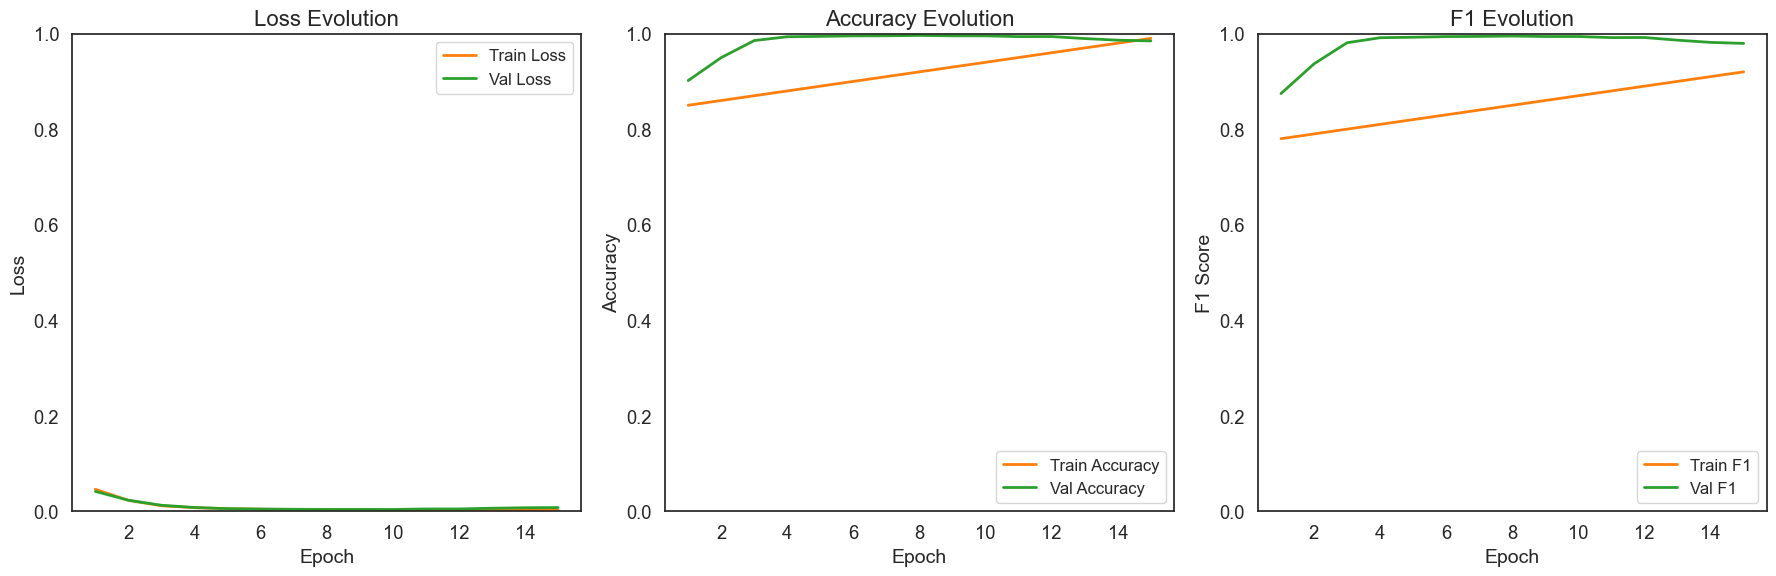

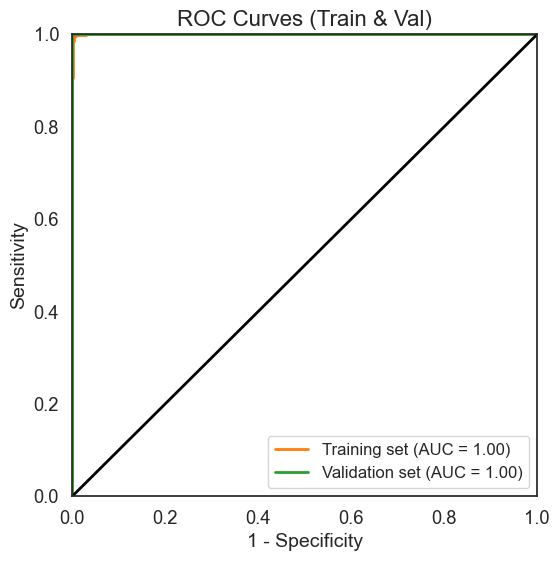

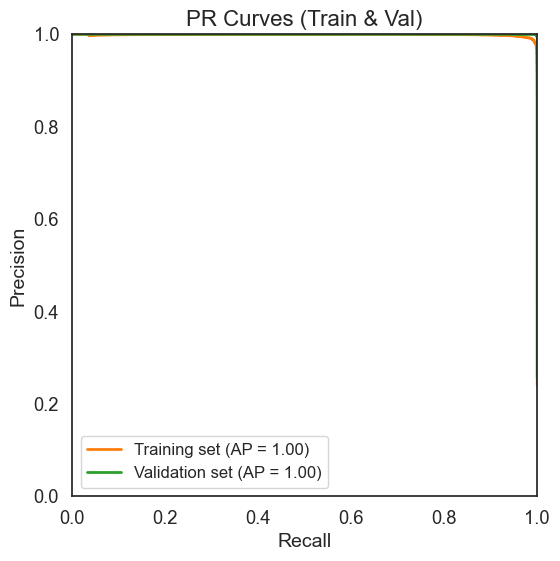

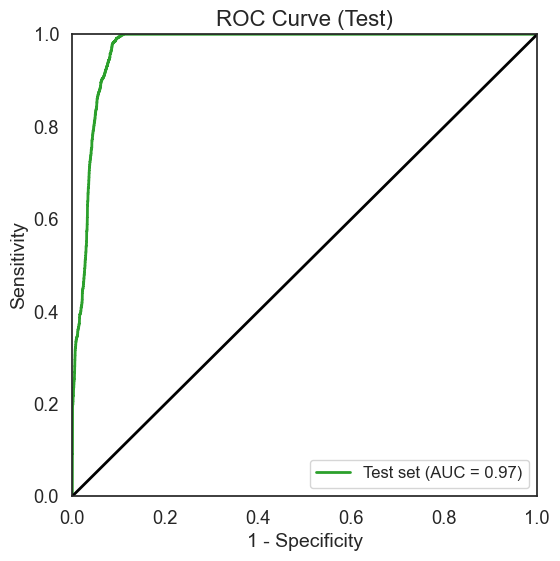

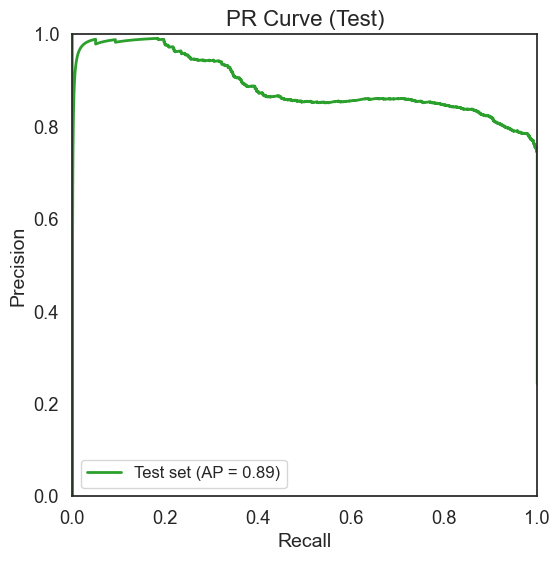

In [67]:
if __name__ == "__main__":
    plot_evolutions(epochs, train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s)
    plot_train_val_roc(y_train_true, y_train_probs, y_val_true, y_val_probs)
    plot_train_val_pr(y_train_true, y_train_probs, y_val_true, y_val_probs)
    plot_test_roc(y_test_true, y_test_probs)
    plot_test_pr(y_test_true, y_test_probs)

In [46]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
def plot_roc_all(y_train_true, y_train_probs,
                 y_val_true, y_val_probs,
                 y_test_true, y_test_probs):
    fpr_tr, tpr_tr, _ = roc_curve(y_train_true, y_train_probs)
    fpr_va, tpr_va, _ = roc_curve(y_val_true, y_val_probs)
    fpr_te, tpr_te, _ = roc_curve(y_test_true, y_test_probs)
    auc_tr = auc(fpr_tr, tpr_tr)
    auc_va = auc(fpr_va, tpr_va)
    auc_te = auc(fpr_te, tpr_te)
    sns.set(style="white", font_scale=1.3)
    plt.figure(figsize=(6.5, 6.5))
    plt.plot(
        fpr_tr, tpr_tr,
        color="#D55E00", lw=2.5, marker='o', markersize=3,
        label=f"Train (AUC = {auc_tr:.3f})", zorder=3
    )
    plt.plot(
        fpr_va, tpr_va,
        color="#009E73", lw=2.5, marker='s', markersize=3,
        label=f"Validation (AUC = {auc_va:.3f})", zorder=2
    )
    plt.plot(
        fpr_te, tpr_te,
        color="#0072B2", lw=2.5, marker='^', markersize=3,
        label=f"Test (AUC = {auc_te:.3f})", zorder=1
    )
    plt.plot([0, 1], [0, 1], '--', color="#7F7F7F", lw=1.5)
    # 关键：避免与边框完全重合
    plt.xlim(-0.01, 1.01)
    plt.ylim(-0.01, 1.01)
    plt.xlabel("1 − Specificity", fontsize=14)
    plt.ylabel("Sensitivity", fontsize=14)
    plt.title("ROC Curves", fontsize=16)

    plt.legend(loc="lower right", frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig("ROC_Train_Val_Test.png", dpi=300)
    plt.show()

In [47]:
from sklearn.metrics import precision_recall_curve, average_precision_score
def plot_pr_all(y_train_true, y_train_probs,
                y_val_true, y_val_probs,
                y_test_true, y_test_probs):
    p_tr, r_tr, _ = precision_recall_curve(y_train_true, y_train_probs)
    p_va, r_va, _ = precision_recall_curve(y_val_true, y_val_probs)
    p_te, r_te, _ = precision_recall_curve(y_test_true, y_test_probs)
    ap_tr = average_precision_score(y_train_true, y_train_probs)
    ap_va = average_precision_score(y_val_true, y_val_probs)
    ap_te = average_precision_score(y_test_true, y_test_probs)
    sns.set(style="white", font_scale=1.3)
    plt.figure(figsize=(6.5, 6.5))
    plt.plot(
        r_tr, p_tr,
        color="#D55E00", lw=2.5, marker='o', markersize=3,
        label=f"Train (AP = {ap_tr:.3f})", zorder=3
    )
    plt.plot(
        r_va, p_va,
        color="#009E73", lw=2.5, marker='s', markersize=3,
        label=f"Validation (AP = {ap_va:.3f})", zorder=2
    )
    plt.plot(
        r_te, p_te,
        color="#0072B2", lw=2.5, marker='^', markersize=3,
        label=f"Test (AP = {ap_te:.3f})", zorder=1
    )
    # 关键：给 Precision=1 留可视空间
    plt.xlim(-0.01, 1.01)
    plt.ylim(0.95, 1.01)
    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision–Recall Curves", fontsize=16)
    plt.legend(loc="lower left", frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig("PR_Train_Val_Test.png", dpi=300)
    plt.show()

In [ ]:
if __name__ == "__main__":
    plot_evolutions(epochs, train_losses, val_losses, train_accuracies, val_accuracies, train_f1s, val_f1s)
    plot_train_val_roc(y_train_true, y_train_probs, y_val_true, y_val_probs)
    plot_train_val_pr(y_train_true, y_train_probs, y_val_true, y_val_probs)
    plot_test_roc(y_test_true, y_test_probs)
    plot_test_pr(y_test_true, y_test_probs)

In [59]:
def figure2A_ROC_all(y_train_true, y_train_probs,
                     y_val_true, y_val_probs,
                     y_test_true, y_test_probs):

    from sklearn.metrics import roc_curve, auc
    sns.set(style="white", font_scale=1.3)
    plt.figure(figsize=(6.5, 6.5))

    colors = {
        "Train": "#D55E00",
        "Val":   "#009E73",
        "Test":  "#0072B2"
    }

    for name, y_true, y_prob in [
        ("Train", y_train_true, y_train_probs),
        ("Validation", y_val_true, y_val_probs),
        ("Test", y_test_true, y_test_probs)
    ]:
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_score = auc(fpr, tpr)
        plt.plot(
            fpr, tpr,
            lw=1.9, color=colors[name if name != "Validation" else "Val"],
            label=f"{name} (AUC = {auc_score:.3f})"
        )

    plt.plot([0,1],[0,1],'--',color='grey')
    plt.xlim(-0.01,1.01)
    plt.ylim(-0.01,1.01)
    plt.xlabel("1 - Specificity")
    plt.ylabel("Sensitivity")
    plt.title("Figure 2A | ROC Curves")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig("Figure2A_ROC.svg", dpi=300)
    plt.show()


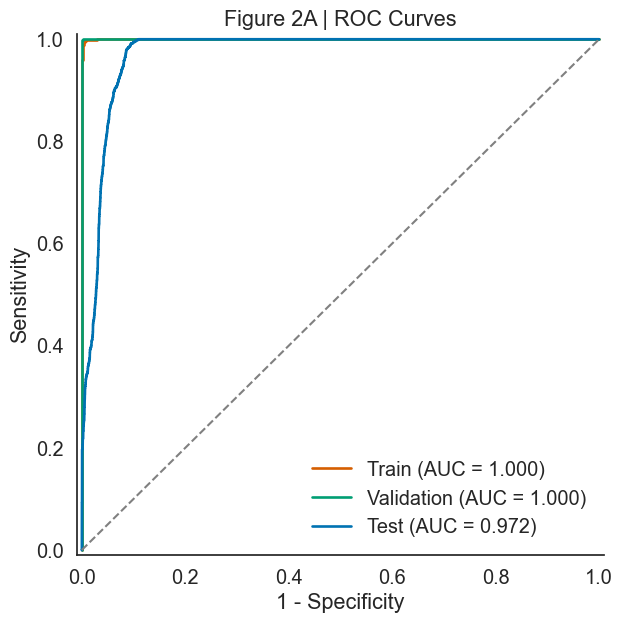

In [60]:
if __name__ == "__main__":
    figure2A_ROC_all(y_train_true, y_train_probs,
                     y_val_true, y_val_probs,
                     y_test_true, y_test_probs)

In [61]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pr_all(y_train_true, y_train_probs,
                y_val_true, y_val_probs,
                y_test_true, y_test_probs):

    # 计算 PR
    p_tr, r_tr, _ = precision_recall_curve(y_train_true, y_train_probs)
    p_va, r_va, _ = precision_recall_curve(y_val_true, y_val_probs)
    p_te, r_te, _ = precision_recall_curve(y_test_true, y_test_probs)

    ap_tr = average_precision_score(y_train_true, y_train_probs)
    ap_va = average_precision_score(y_val_true, y_val_probs)
    ap_te = average_precision_score(y_test_true, y_test_probs)

    sns.set(style="white", font_scale=1.3)
    plt.figure(figsize=(6.5, 6.5))

    # Train
    plt.plot(
        r_tr, p_tr,
        color="#D55E00",
        lw=1.9,
        alpha=0.95,
        label=f"Train (AP = {ap_tr:.3f})",
        zorder=3
    )

    # Validation
    plt.plot(
        r_va, p_va,
        color="#009E73",
        lw=1.9,
        alpha=0.95,
        label=f"Validation (AP = {ap_va:.3f})",
        zorder=2
    )

    # Test
    plt.plot(
        r_te, p_te,
        color="#0072B2",
        lw=1.9,
        alpha=0.95,
        label=f"Test (AP = {ap_te:.3f})",
        zorder=1
    )

    # ✅ 坐标轴必须是完整 0–1
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)

    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision–Recall Curves", fontsize=16)

    plt.legend(loc="lower left", frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig("PR_Train_Val_Test.svg", dpi=300)
    plt.show()

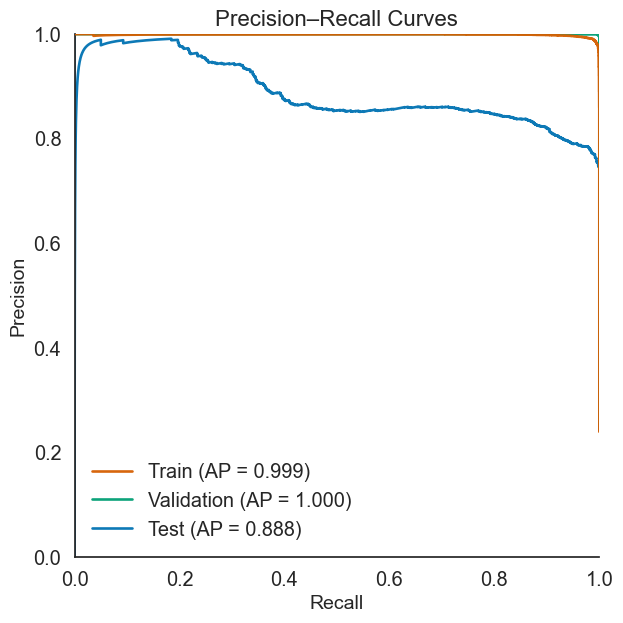

In [63]:
if __name__ == "__main__":
    plot_pr_all(y_train_true, y_train_probs,
                     y_val_true, y_val_probs,
                     y_test_true, y_test_probs)

In [64]:
def figure2B_PR_all(y_train_true, y_train_probs,
                    y_val_true, y_val_probs,
                    y_test_true, y_test_probs):

    from sklearn.metrics import precision_recall_curve, average_precision_score
    sns.set(style="white", font_scale=1.3)
    plt.figure(figsize=(6.5, 6.5))

    colors = {
        "Train": "#D55E00",
        "Val":   "#009E73",
        "Test":  "#0072B2"
    }

    for name, y_true, y_prob in [
        ("Train", y_train_true, y_train_probs),
        ("Validation", y_val_true, y_val_probs),
        ("Test", y_test_true, y_test_probs)
    ]:
        p, r, _ = precision_recall_curve(y_true, y_prob)
        ap = average_precision_score(y_true, y_prob)
        plt.plot(
            r, p,
            lw=2.2, color=colors[name if name != "Validation" else "Val"],
            label=f"{name} (AP = {ap:.3f})"
        )

    plt.xlim(-0.01,1.01)
    plt.ylim(0,1)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Figure 2B | Precision–Recall Curves")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.savefig("Figure2B_PR.svg", dpi=300)
    plt.show()


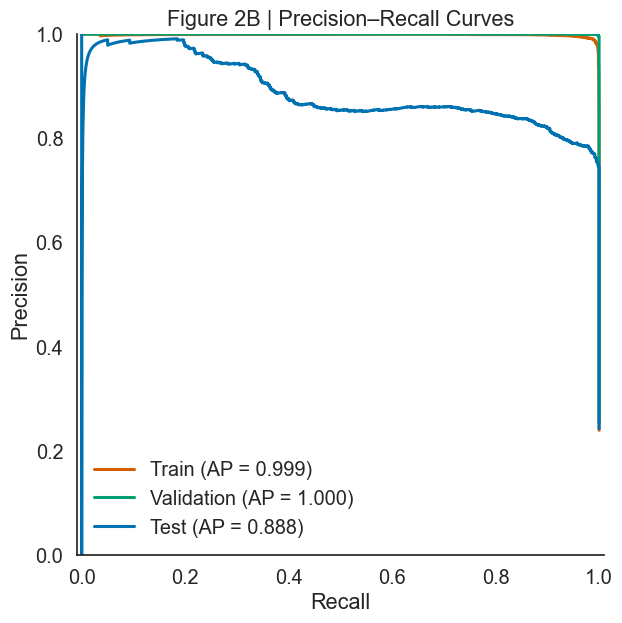

In [65]:
if __name__ == "__main__":
    figure2B_PR_all(y_train_true, y_train_probs,
                    y_val_true, y_val_probs,
                    y_test_true, y_test_probs)

In [72]:
from sklearn.metrics import confusion_matrix

def figure2C_confusion(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)

    sns.set(font_scale=1.4)
    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["nonHR", "HR"],
        yticklabels=["nonHR", "HR"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Figure 2C | Confusion Matrix (Test)")
    plt.tight_layout()
    plt.savefig("Figure2C_CM.svg", dpi=300)
    plt.show()


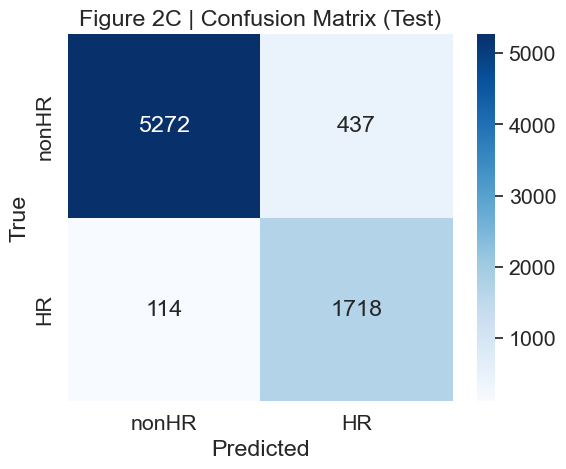

In [73]:
if __name__ == "__main__":
    figure2C_confusion(y_test_true, y_test_probs)

In [74]:
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score, average_precision_score

def figure2D_metrics(y_true, y_probs):
    y_pred = (y_probs >= 0.5).astype(int)

    metrics = {
        "AUC": roc_auc_score(y_true, y_probs),
        "AP": average_precision_score(y_true, y_probs),
        "F1": f1_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred)
    }

    sns.set(style="white", font_scale=1.2)
    plt.figure(figsize=(5.5,4))
    sns.barplot(
        x=list(metrics.keys()),
        y=list(metrics.values()),
        color="#0072B2"
    )
    plt.ylim(0.9,1.01)
    plt.ylabel("Score")
    plt.title("Figure 2D | Test Performance")
    sns.despine()
    plt.tight_layout()
    plt.savefig("Figure2D_Metrics.svg", dpi=300)
    plt.show()


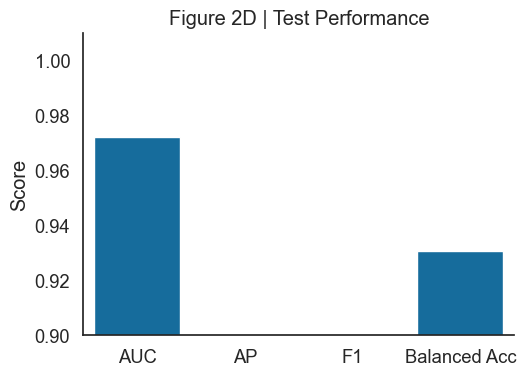

In [75]:
if __name__ == "__main__":
    figure2D_metrics(y_test_true, y_test_probs)

In [ ]:
# Unknown data prediction
unknown_df = pd.read_csv('C:/Users/wenzh/Desktop/Model_test/unknown_input_data.csv')

In [46]:
Xg_unknown, ct_unknown, cell_unknown, hpv_unknown, seqA_props_unknown, seqB_props_unknown, seqA_len_unknown, seqB_len_unknown, freq_unknown, y_unknown = mapper.transform(unknown_df, has_label=False)
unknown_dataset = TCellDataset(Xg_unknown, ct_unknown, cell_unknown, hpv_unknown, seqA_props_unknown, seqB_props_unknown, seqA_len_unknown, seqB_len_unknown, freq_unknown, y=None)
unknown_loader = DataLoader(unknown_dataset, batch_size=256, shuffle=False)

Shape of gene feature matrix: (27365, 17974)


In [ ]:
model.eval()
all_unknown_probs = []
with torch.no_grad():
    for batch in tqdm(unknown_loader, desc='Predicting Unknown'):
        features = [x.to(device) for x in batch] 
        logits = model(*features)
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        all_unknown_probs.extend(probs)

Predicting Unknown: 100%|██████████| 107/107 [00:06<00:00, 16.89it/s]


In [60]:
# Extract Neo TCR keys from training set
train_set['TCR_key'] = train_set['CTgene'] + '|' + train_set['cdr3_aa1'] + '|' + train_set['cdr3_aa2']
train_neo_tcr_set = set(train_set[train_set['Label'] == 'Neo']['TCR_key'])
corrected_preds, raw_probs = post_process_tcr_consistency(unknown_df, all_unknown_probs, train_neo_tcr_set)

TCR Consistency Check: 1501 cells had their labels corrected based on TCR identity and majority voting.


In [61]:
all_ids = unknown_df['ID'].tolist()
predicted_labels = ['Neo' if p == 1 else 'nonNeo' for p in corrected_preds]

output_df = pd.DataFrame({
    'ID': all_ids,
    'Predicted_Label': predicted_labels,
    'Probability_Raw': raw_probs,
})
output_df.to_csv('predicted_unknown_corrected.csv', index=False)
print("Predictions (with TCR consistency correction) exported to predicted_unknown_corrected.csv")

Predictions (with TCR consistency correction) exported to predicted_unknown_corrected.csv
